In [9]:
import sys
print(sys.executable)

c:\Users\aymie\Documents\UK_projects\masters-proj\my_extensions\reintegration\output\partition\meld\venv\Scripts\python.exe


In [10]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

LABEL_NAMES = ["angry", "happy", "sad", "neutral", "excited", "frustrated"]

COLOR_PALETTE = sns.color_palette("husl", 6)

with open("partition.json") as f:
    partition = json.load(f)

client_ids = sorted([k for k in partition if k not in ("dev", "test")], key=int)

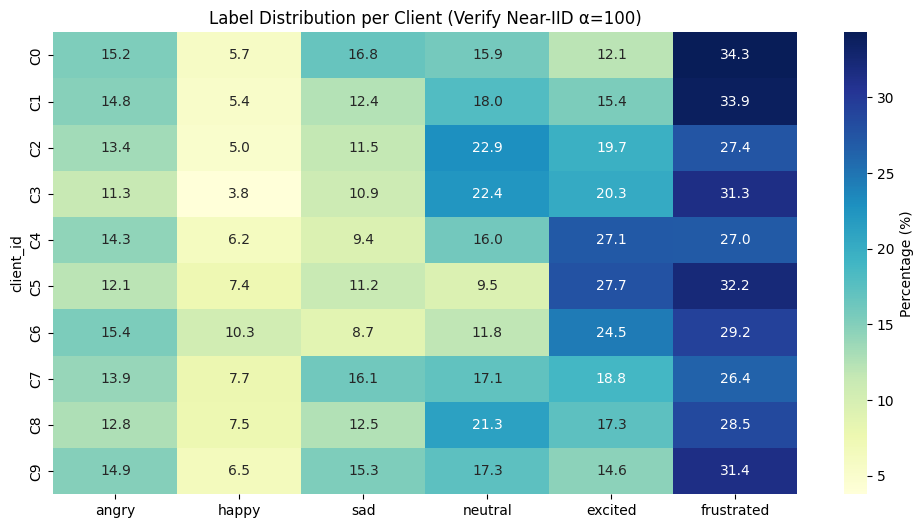

,angry,happy,sad,neutral,excited,frustrated
min,11.313394,3.771131,8.743842,9.476309,12.071156,26.400996
max,15.394089,10.344828,16.772554,22.932331,27.680798,34.307497
mean,13.820924,6.554936,12.499039,17.219498,19.738967,30.166636


In [11]:
client_data = []

for cid in client_ids:
    scenes = partition[cid]
    counts = Counter(utt[2] for scene in scenes for utt in scene)
    total = sum(counts.values())
    
    dist = {LABEL_NAMES[i]: (counts.get(i, 0) / total * 100) for i in range(6)}
    dist['client_id'] = f"C{cid}"
    client_data.append(dist)

df_clients = pd.DataFrame(client_data).set_index('client_id')

plt.figure(figsize=(12, 6))
sns.heatmap(df_clients, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'})
plt.title("Label Distribution per Client (Verify Near-IID α=100)")
plt.show()

display(df_clients.describe().loc[['min', 'max', 'mean']])

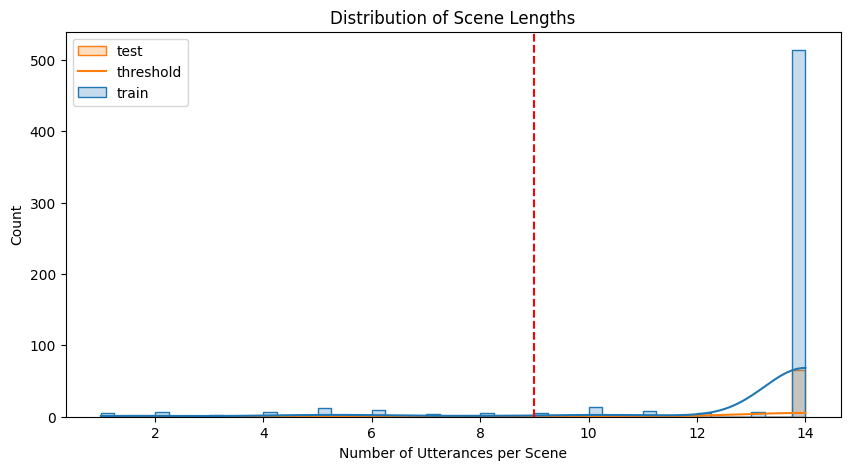

Average Scene Length: 13.03
Percentage of scenes at minimum (length 9): 0.9%


In [12]:
all_lengths = []
for cid in client_ids + ["test"]:
    for scene in partition[cid]:
        all_lengths.append({
            'subset': 'train' if cid in client_ids else 'test',
            'length': len(scene)
        })

df_lengths = pd.DataFrame(all_lengths)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_lengths, x='length', hue='subset', kde=True, element="step")
plt.axvline(x=9, color='red', linestyle='--', label='Min Length Threshold')
plt.title("Distribution of Scene Lengths")
plt.xlabel("Number of Utterances per Scene")
plt.ylabel("Count")
plt.legend(['test','threshold', 'train'])
plt.show()

print(f"Average Scene Length: {df_lengths['length'].mean():.2f}")
print(f"Percentage of scenes at minimum (length 9): {(df_lengths['length'] == 9).mean()*100:.1f}%")

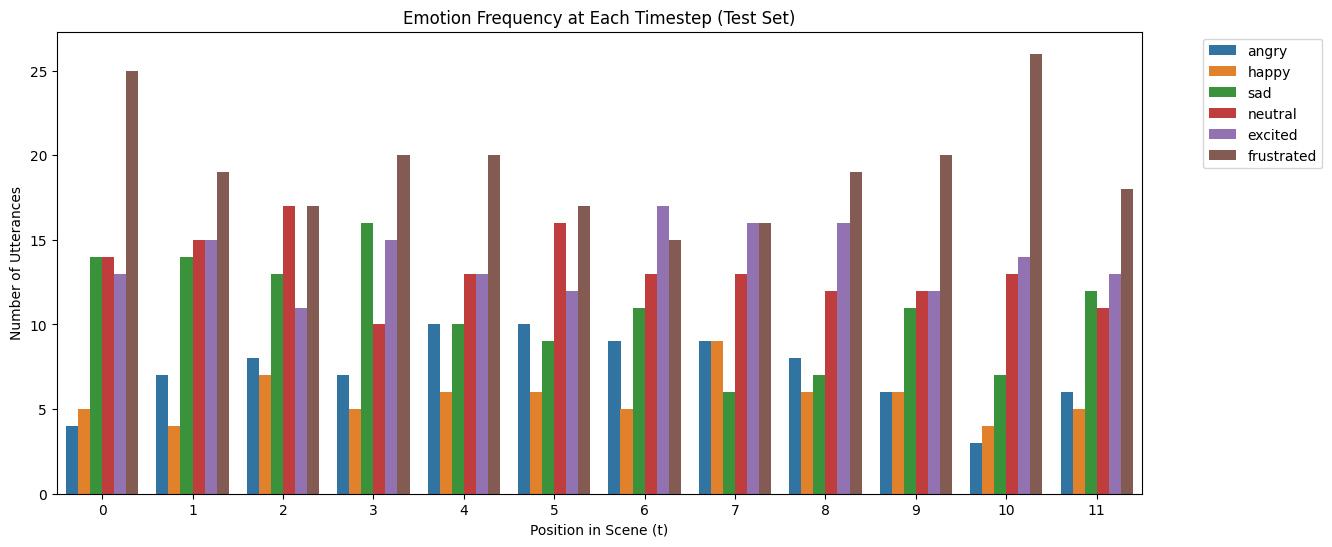

In [13]:
pos_data = []
test_scenes = partition["test"]
for scene in test_scenes:
    for pos, utt in enumerate(scene):
        pos_data.append({'position': pos, 'label': LABEL_NAMES[utt[2]]})
df_pos = pd.DataFrame(pos_data)
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df_pos[df_pos['position'] < 12],
    x='position',
    hue='label',
    hue_order=list(LABEL_NAMES),
)
plt.title("Emotion Frequency at Each Timestep (Test Set)")
plt.xlabel("Position in Scene (t)")
plt.ylabel("Number of Utterances")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

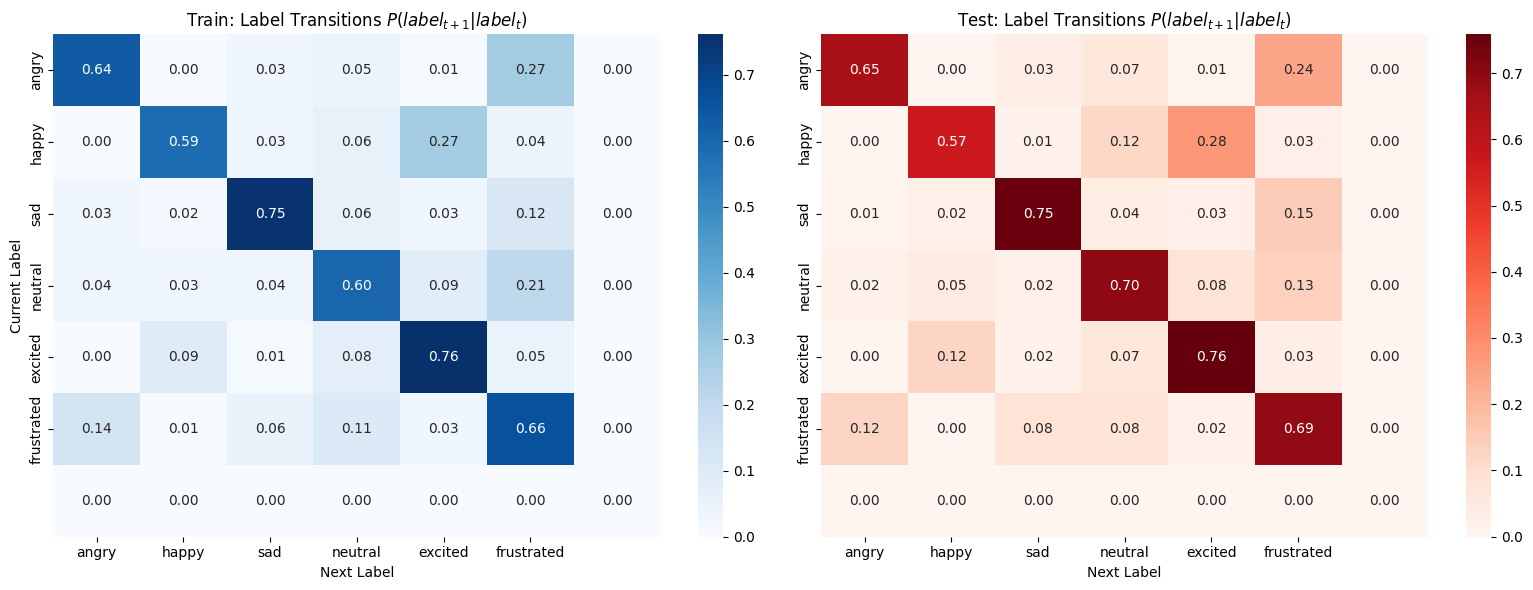

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def get_transition_matrix(scenes, num_classes=7):
    matrix = np.zeros((num_classes, num_classes))
    
    for scene in scenes:
        labels = [utt[2] for utt in scene]
        for i in range(len(labels) - 1):
            current_label = labels[i]
            next_label = labels[i+1]
            matrix[current_label][next_label] += 1
            
    # Normalize rows to represent probabilities: P(next | current)
    # Adding a small epsilon to avoid division by zero
    row_sums = matrix.sum(axis=1, keepdims=True) + 1e-9
    norm_matrix = matrix / row_sums
    return norm_matrix

train_scenes = [s for cid in client_ids for s in partition[cid]]
test_scenes = partition["test"]

train_mtx = get_transition_matrix(train_scenes)
test_mtx = get_transition_matrix(test_scenes)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
labels = [LABEL_NAMES[i] for i in range(6)]

sns.heatmap(train_mtx, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=labels, yticklabels=labels, ax=ax[0])
ax[0].set_title("Train: Label Transitions $P(label_{t+1} | label_t)$")
ax[0].set_xlabel("Next Label")
ax[0].set_ylabel("Current Label")

sns.heatmap(test_mtx, annot=True, fmt=".2f", cmap="Reds", 
            xticklabels=labels, yticklabels=labels, ax=ax[1])
ax[1].set_title("Test: Label Transitions $P(label_{t+1} | label_t)$")
ax[1].set_xlabel("Next Label")

plt.tight_layout()
plt.show()

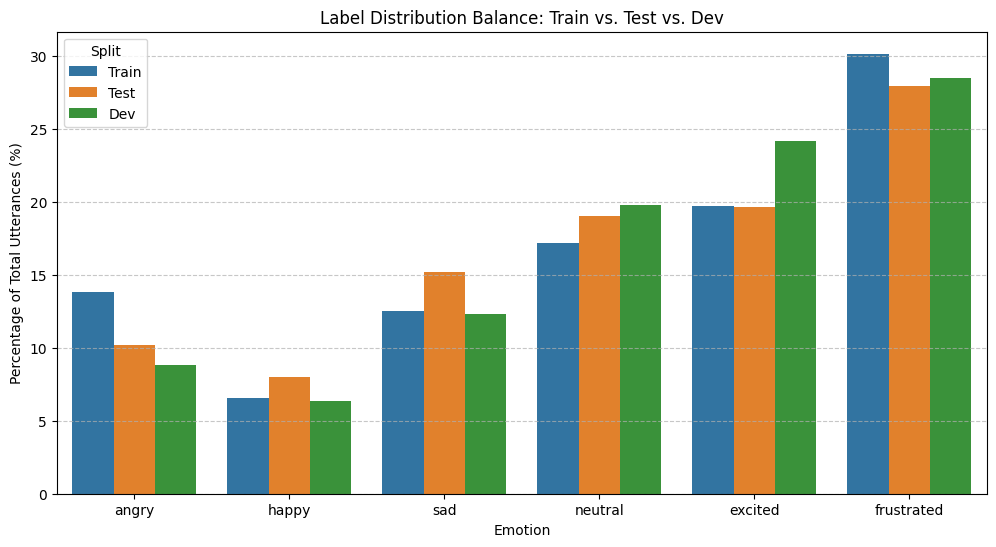

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

split_data = []
for split_name in ["train", "test", "dev"]:
    if split_name == "train":
        scenes = [s for cid in client_ids for s in partition[cid]]
    else:
        scenes = partition[split_name]
    
    counts = Counter(utt[2] for scene in scenes for utt in scene)
    total = sum(counts.values())
    
    for label_id, label_name in enumerate(LABEL_NAMES):
        split_data.append({
            "Split": split_name.capitalize(),
            "Emotion": label_name,
            "Percentage": (counts.get(label_id, 0) / total) * 100
        })

df_split_labels = pd.DataFrame(split_data)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_split_labels, x="Emotion", y="Percentage", hue="Split")
plt.title("Label Distribution Balance: Train vs. Test vs. Dev")
plt.ylabel("Percentage of Total Utterances (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

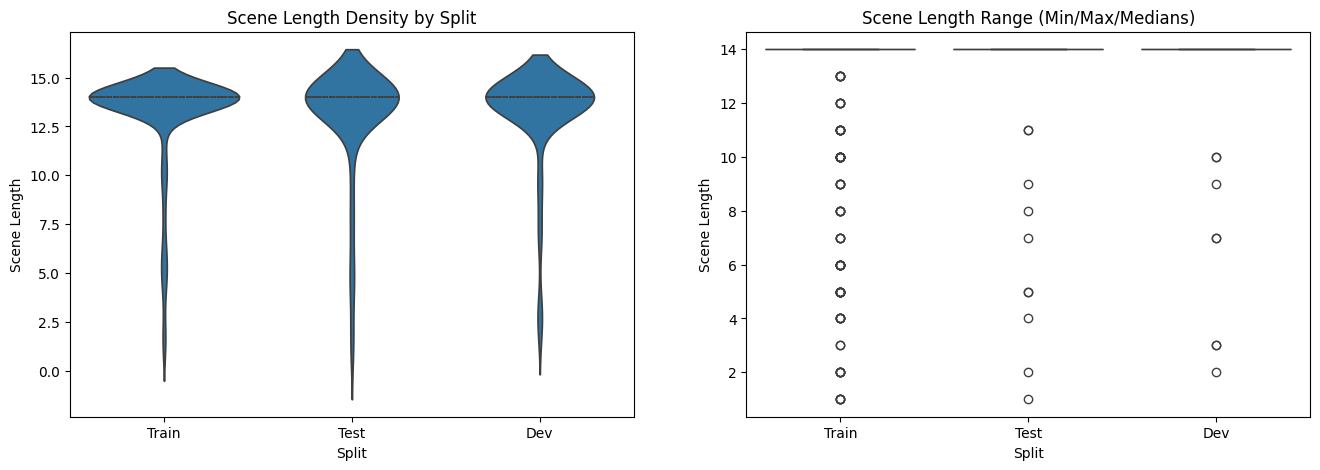


Scene Metric Summary


,count,min,max,mean,median
Split,,,,,
Dev,75,2,14,13.19,14.0
Test,75,1,14,12.97,14.0
Train,601,1,14,13.03,14.0


In [16]:
length_data = []
for split_name in ["train", "test", "dev"]:
    if split_name == "train":
        scenes = [s for cid in client_ids for s in partition[cid]]
    else:
        scenes = partition[split_name]
        
    for scene in scenes:
        length_data.append({
            "Split": split_name.capitalize(),
            "Scene Length": len(scene)
        })

df_lengths = pd.DataFrame(length_data)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.violinplot(data=df_lengths, x="Split", y="Scene Length", ax=ax[0], inner="quart")
ax[0].set_title("Scene Length Density by Split")
sns.boxplot(data=df_lengths, x="Split", y="Scene Length", ax=ax[1])
ax[1].set_title("Scene Length Range (Min/Max/Medians)")

plt.show()

print("\nScene Metric Summary")
# print(df_lengths.groupby("Split")["Scene", "Length"].agg(['count', 'min', 'max', 'mean', 'median']).round(2))
display(df_lengths.groupby("Split")["Scene Length"].agg(['count', 'min', 'max', 'mean', 'median']).round(2))


apply a Markov availability mask to the audio modality. Text remains available at all utterances. The mask governs whether the audio feature vector is passed to the fusion module or replaced with a zero vector / mask token. A reintegration event occurs when audio transitions from absent to present, while text availability is uninterrupted



* Partition:   10 clients, using dirichelet distribution and α=100, IID
* Scenes:      487 train, 62 dev, 143 test
* Training:    two passes per scene per round (stable + masked)
* Masking:     audio only, text always present
* Mask params: P(a→a)=0.7, P(p→p)=0.75, fixed seed=scene_id
* Evaluation:  within-scene contrast, delta at t_reint
* Metric:      UAR per condition, mean delta across reint events


Evaluate the WITHIN-CONDITION contrast.
Both conditions see the same label distribution
at every timestep (same scenes, same labels). Hopefully the imbalance affects both conditions identically. Since I'm meauring relative degradation, not absolute accuracy, imbalance will shift both conditions equally so it does not confound the delta.
ex.
- If neutral dominates at t=5:
    - stable condition:  mostly predicts neutral at t=5
    - reint  condition:  mostly predicts neutral at t=5
    - delta:             neutral bias cancels out


Phase 1 (core contribution):

Audio masked, text stable
- establish phenomenon exists
- build and evaluate regulation mechanism
- this is primary result

Phase 2 (extension, if time permits):
Text masked, audio stable
- does the same dip appear for the other modality?
- symmetric validation of the phenomenon

Extensions to explore:
Dual modality masking 
- "does the dip depend on what fallback signal is available?"
- this question, requires first question to be answered
    (future work, probably not in this project):
    - Dual masking with independent Markov chains
    - stress test of regulation under complex availability

Regulation Mechanism:

<br>If dip occurs, extend into a regulation mechanism (something to control the reintegration effect) 
<br>that relies on availability history as a signal. 
<br>Experiment whether it works when availability history is complex:

Simple history:    
- audio absent for 3 turns → returns
- text always present
- easy to detect and regulate

Complex history (stress test of the solution, not a test of whether the problem exists):   
- audio absent, text also intermittently absent
- availability signal is noisier
- regulation is harder